# 10 Minutes to pandas

Dieses Notebook ist eine kompakte, projektlokale Variante der bekannten `10 Minutes to pandas`-Einfuhrung. Es nutzt den Kernel aus der `.venv` dieses Projekts.

Die Erklarungen sind bewusst etwas ausfuhrlicher gehalten, damit du beim Ausfuhren direkt siehst, was in jeder Zelle gerade passiert.

## Setup

Falls dein Editor den Kernel nicht automatisch setzt, wahle `Python (.venv) - 260324-lv3` aus.

In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 120)

print("Bibliotheken geladen: numpy, pandas, matplotlib")
print("Die Anzeigeoptionen wurden etwas kompakter fur Notebook-Ausgaben gesetzt.")

Bibliotheken geladen: numpy, pandas, matplotlib
Die Anzeigeoptionen wurden etwas kompakter fur Notebook-Ausgaben gesetzt.


## 1. Objekte erzeugen

Wir starten mit den beiden wichtigsten pandas-Strukturen:

- `Series`: eine einzelne beschriftete Spalte
- `DataFrame`: eine tabellarische Struktur mit Zeilen und Spalten

In [2]:
print("Wir erzeugen zuerst eine Series. pandas vergibt automatisch einen Integer-Index.")
s = pd.Series([1, 3, 5, np.nan, 6, 8])
display(s)

print("Das NaN steht fur einen fehlenden Wert.")

Wir erzeugen zuerst eine Series. pandas vergibt automatisch einen Integer-Index.


0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

Das NaN steht fur einen fehlenden Wert.


In [3]:
print("Jetzt bauen wir ein DataFrame mit Datumsindex und vier numerischen Spalten.")
dates = pd.date_range("2026-01-01", periods=6)
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))
display(df)

print("Jede Zeile ist hier uber ein Datum identifizierbar.")

Jetzt bauen wir ein DataFrame mit Datumsindex und vier numerischen Spalten.


,A,B,C,D
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-02,-0.450053,0.701662,-0.313922,0.072660
2026-01-03,0.567786,0.443814,-0.852549,0.703371
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888
2026-01-05,-0.496390,-0.034001,-0.035085,-0.354269
2026-01-06,0.813263,-0.175466,1.262870,1.951635


Jede Zeile ist hier uber ein Datum identifizierbar.


In [4]:
print("pandas kann in einem DataFrame auch gemischte Datentypen verwalten.")
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("2026-01-01"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "hello",
    }
)
display(df2)
print("Hier sieht man Zahlen, Datum, Kategorie und Text in einer Tabelle.")

pandas kann in einem DataFrame auch gemischte Datentypen verwalten.


,A,B,C,D,E,F
0,1.0,2026-01-01,1.0,3,test,hello
1,1.0,2026-01-01,1.0,3,train,hello
2,1.0,2026-01-01,1.0,3,test,hello
3,1.0,2026-01-01,1.0,3,train,hello


Hier sieht man Zahlen, Datum, Kategorie und Text in einer Tabelle.


## 2. Daten ansehen

Bevor man mit Daten arbeitet, schaut man sich typischerweise Struktur, Kopfzeilen, Kennzahlen und Sortierung an.

In [5]:
print("head(): zeigt die ersten Zeilen fur einen schnellen Uberblick")
display(df.head())

print("tail(3): zeigt die letzten drei Zeilen")
display(df.tail(3))

print("index: der Zeilenindex des DataFrames")
display(df.index)

print("columns: die Spaltennamen")
display(df.columns)

print("to_numpy(): reine NumPy-Darstellung ohne Index und Spaltenbeschriftung")
display(df.to_numpy())

print("describe(): statistische Grundzusammenfassung fur numerische Spalten")
display(df.describe())

print("T: transponiert das DataFrame, also Zeilen und Spalten werden getauscht")
display(df.T)

print("sort_index(...): sortiert nach Spaltennamen statt nach Werten")
display(df.sort_index(axis=1, ascending=False))

print("sort_values(by='B'): sortiert die Zeilen nach den Werten in Spalte B")
display(df.sort_values(by="B"))

head(): zeigt die ersten Zeilen fur einen schnellen Uberblick


,A,B,C,D
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-02,-0.450053,0.701662,-0.313922,0.072660
2026-01-03,0.567786,0.443814,-0.852549,0.703371
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888
2026-01-05,-0.496390,-0.034001,-0.035085,-0.354269


tail(3): zeigt die letzten drei Zeilen


,A,B,C,D
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888
2026-01-05,-0.496390,-0.034001,-0.035085,-0.354269
2026-01-06,0.813263,-0.175466,1.262870,1.951635


index: der Zeilenindex des DataFrames


...

,2026-01-01,2026-01-02,2026-01-03,2026-01-04,2026-01-05,2026-01-06
A,0.939088,-0.450053,0.567786,-0.477088,-0.496390,0.813263
B,0.076129,0.701662,0.443814,-0.244998,-0.034001,-0.175466
C,1.152824,-0.313922,-0.852549,-1.425341,-0.035085,1.262870
D,0.342113,0.072660,0.703371,0.039888,-0.354269,1.951635


sort_index(...): sortiert nach Spaltennamen statt nach Werten


,D,C,B,A
2026-01-01,0.342113,1.152824,0.076129,0.939088
2026-01-02,0.072660,-0.313922,0.701662,-0.450053
2026-01-03,0.703371,-0.852549,0.443814,0.567786
2026-01-04,0.039888,-1.425341,-0.244998,-0.477088
2026-01-05,-0.354269,-0.035085,-0.034001,-0.496390
2026-01-06,1.951635,1.262870,-0.175466,0.813263


sort_values(by='B'): sortiert die Zeilen nach den Werten in Spalte B


,A,B,C,D
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888
2026-01-06,0.813263,-0.175466,1.262870,1.951635
2026-01-05,-0.496390,-0.034001,-0.035085,-0.354269
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-03,0.567786,0.443814,-0.852549,0.703371
2026-01-02,-0.450053,0.701662,-0.313922,0.072660


## 3. Auswahl und Zugriff

Jetzt greifen wir auf einzelne Spalten, Teilbereiche und bestimmte Positionen zu.

In [6]:
print("df['A']: holt eine einzelne Spalte als Series")
display(df["A"])

print("df[0:3]: Zeilenschnitt uber Positionen")
display(df[0:3])

print("loc[...]: label-basierter Zugriff, hier eine Zeile uber ihr Datum")
display(df.loc[dates[0]])

print("loc[:, ['A', 'B']]: alle Zeilen, aber nur die Spalten A und B")
display(df.loc[:, ["A", "B"]])

print("iloc[3]: positionsbasierter Zugriff auf die vierte Zeile")
display(df.iloc[3])

print("iloc[3:5, 0:2]: Zeilen 4-5 und Spalten 1-2 nach Position")
display(df.iloc[3:5, 0:2])

print("Mehrfachauswahl mit iloc fur bestimmte Zeilen- und Spaltenpositionen")
display(df.iloc[[1, 2, 4], [0, 2]])

print("Boolean Filtering: nur Zeilen, in denen Spalte A grosser als 0 ist")
display(df[df["A"] > 0])

df['A']: holt eine einzelne Spalte als Series


2026-01-01    0.939088
2026-01-02   -0.450053
2026-01-03    0.567786
2026-01-04   -0.477088
2026-01-05   -0.496390
2026-01-06    0.813263
Freq: D, Name: A, dtype: float64

df[0:3]: Zeilenschnitt uber Positionen


,A,B,C,D
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-02,-0.450053,0.701662,-0.313922,0.072660
2026-01-03,0.567786,0.443814,-0.852549,0.703371


loc[...]: label-basierter Zugriff, hier eine Zeile uber ihr Datum


...

,A,B
2026-01-04,-0.477088,-0.244998
2026-01-05,-0.496390,-0.034001


Mehrfachauswahl mit iloc fur bestimmte Zeilen- und Spaltenpositionen


,A,C
2026-01-02,-0.450053,-0.313922
2026-01-03,0.567786,-0.852549
2026-01-05,-0.496390,-0.035085


Boolean Filtering: nur Zeilen, in denen Spalte A grosser als 0 ist


,A,B,C,D
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-03,0.567786,0.443814,-0.852549,0.703371
2026-01-06,0.813263,-0.175466,1.262870,1.951635


## 4. Werte setzen

Wir arbeiten auf einer Kopie, damit das ursprungliche `df` unverandert bleibt.

In [7]:
df_copy = df.copy()
print("loc setzt einen Wert uber Zeilenlabel und Spaltenname.")
df_copy.loc[dates[0], "A"] = 0

print("iloc setzt einen Wert uber numerische Position.")
df_copy.iloc[1, 1] = 0

print("Hier fugen wir eine neue Spalte E hinzu.")
df_copy["E"] = ["one", "one", "two", "three", "four", "three"]
display(df_copy)

print("Das Ergebnis ist ein geandertes DataFrame mit zusatzlicher Textspalte.")

loc setzt einen Wert uber Zeilenlabel und Spaltenname.
iloc setzt einen Wert uber numerische Position.
Hier fugen wir eine neue Spalte E hinzu.


,A,B,C,D,E
2026-01-01,0.000000,0.076129,1.152824,0.342113,one
2026-01-02,-0.450053,0.000000,-0.313922,0.072660,one
2026-01-03,0.567786,0.443814,-0.852549,0.703371,two
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888,three
2026-01-05,-0.496390,-0.034001,-0.035085,-0.354269,four
2026-01-06,0.813263,-0.175466,1.262870,1.951635,three


Das Ergebnis ist ein geandertes DataFrame mit zusatzlicher Textspalte.


## 5. Fehlende Daten

Fehlende Werte sind im Alltag sehr haufig. pandas bietet dafUr viele eingebaute Werkzeuge.

In [8]:
df_missing = df.reindex(index=dates[:4], columns=list(df.columns) + ["E"])
df_missing.loc[dates[0] : dates[1], "E"] = 1

print("reindex() erzeugt hier bewusst fehlende Werte, weil neue Struktur angefordert wurde.")
display(df_missing)

print("dropna(how='any'): entfernt alle Zeilen, die mindestens einen fehlenden Wert haben.")
display(df_missing.dropna(how="any"))

print("fillna(value=5): ersetzt fehlende Werte durch einen festen Wert.")
display(df_missing.fillna(value=5))

print("isna(): zeigt fur jede Zelle, ob dort ein fehlender Wert liegt.")
display(pd.isna(df_missing))

reindex() erzeugt hier bewusst fehlende Werte, weil neue Struktur angefordert wurde.


,A,B,C,D,E
2026-01-01,0.939088,0.076129,1.152824,0.342113,1.0
2026-01-02,-0.450053,0.701662,-0.313922,0.072660,1.0
2026-01-03,0.567786,0.443814,-0.852549,0.703371,NaN
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888,NaN


dropna(how='any'): entfernt alle Zeilen, die mindestens einen fehlenden Wert haben.


,A,B,C,D,E
2026-01-01,0.939088,0.076129,1.152824,0.342113,1.0
2026-01-02,-0.450053,0.701662,-0.313922,0.072660,1.0


fillna(value=5): ersetzt fehlende Werte durch einen festen Wert.


,A,B,C,D,E
2026-01-01,0.939088,0.076129,1.152824,0.342113,1.0
2026-01-02,-0.450053,0.701662,-0.313922,0.072660,1.0
2026-01-03,0.567786,0.443814,-0.852549,0.703371,5.0
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888,5.0


isna(): zeigt fur jede Zelle, ob dort ein fehlender Wert liegt.


,A,B,C,D,E
2026-01-01,False,False,False,False,False
2026-01-02,False,False,False,False,False
2026-01-03,False,False,False,False,True
2026-01-04,False,False,False,False,True


## 6. Operationen

Viele Standardoperationen arbeiten direkt spaltenweise oder zeilenweise.

In [9]:
print("mean(): Mittelwert pro Spalte")
display(df.mean())

print("mean(axis=1): Mittelwert pro Zeile")
display(df.mean(axis=1))

print("shift(2): verschiebt eine Series um zwei Zeilen nach unten.")
s_shifted = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)
display(s_shifted)

print("sub(..., axis='index'): subtrahiert entlang des gemeinsamen Index.")
display(df.sub(s_shifted, axis="index"))

print("apply(np.cumsum): kumulative Summe innerhalb jeder Spalte")
display(df.apply(np.cumsum))

print("apply(lambda ...): Spannweite pro Spalte, also max minus min")
display(df.apply(lambda x: x.max() - x.min()))

mean(): Mittelwert pro Spalte


A    0.149434
B    0.127857
C   -0.035200
D    0.459233
dtype: float64

mean(axis=1): Mittelwert pro Zeile


2026-01-01    0.627539
2026-01-02    0.002587
2026-01-03    0.215605
2026-01-04   -0.526885
2026-01-05   -0.229936
2026-01-06    0.963076
Freq: D, dtype: float64

shift(2): verschiebt eine Series um zwei Zeilen nach unten.


...

,A,B,C,D
2026-01-01,NaN,NaN,NaN,NaN
2026-01-02,NaN,NaN,NaN,NaN
2026-01-03,-0.432214,-0.556186,-1.852549,-0.296629
2026-01-04,-3.477088,-3.244998,-4.425341,-2.960112
2026-01-05,-5.496390,-5.034001,-5.035085,-5.354269
2026-01-06,NaN,NaN,NaN,NaN


apply(np.cumsum): kumulative Summe innerhalb jeder Spalte


,A,B,C,D
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-02,0.489036,0.777792,0.838902,0.414772
2026-01-03,1.056822,1.221605,-0.013648,1.118143
2026-01-04,0.579734,0.976607,-1.438988,1.158031
2026-01-05,0.083343,0.942607,-1.474073,0.803762
2026-01-06,0.896607,0.767141,-0.211203,2.755397


apply(lambda ...): Spannweite pro Spalte, also max minus min


A    1.435479
B    0.946660
C    2.688211
D    2.305904
dtype: float64

## 7. Histogramm, Strings und Kategorien

pandas kann auch Haufikeiten zahlen, Text spaltenweise transformieren und Kategorien effizient speichern.

In [10]:
print("value_counts(): zahlt, wie oft jeder Wert vorkommt")
display(pd.Series(np.random.randint(0, 7, size=10)).value_counts())

s_text = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])
print("str.lower(): wendet eine String-Operation auf jedes Element an")
display(s_text.str.lower())

df_cat = df_copy.copy()
df_cat["E"] = df_cat["E"].astype("category")
print("astype('category'): spart oft Speicher und zeigt, dass Spalte E kategorial ist")
display(df_cat.dtypes)

value_counts(): zahlt, wie oft jeder Wert vorkommt


0    3
6    3
1    2
5    2
Name: count, dtype: int64

str.lower(): wendet eine String-Operation auf jedes Element an


0       a
1       b
2       c
3    aaba
4    baca
5     NaN
6    caba
7     dog
8     cat
dtype: str

astype('category'): spart oft Speicher und zeigt, dass Spalte E kategorial ist


A     float64
B     float64
C     float64
D     float64
E    category
dtype: object

## 8. Merge, GroupBy und Reshape

Hier sieht man drei typische Datenaufbereitungsaufgaben:

- Tabellen zusammenfuhren
- nach Gruppen aggregieren
- Daten zwischen langer und breiter Form umformen

In [11]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
print("merge(...): verbindet zwei Tabellen uber die gemeinsame Schlusselspalte 'key'")
display(pd.merge(left, right, on="key"))

df_group = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
print("groupby('A').sum(): aggregiert die Werte je Gruppe in Spalte A")
display(df_group.groupby("A")[["C", "D"]].sum())

print("groupby(['A', 'B']): gruppiert uber zwei Schlussel gleichzeitig")
display(df_group.groupby(["A", "B"])["D"].sum())

stacked = df2.stack(future_stack=True)
print("stack(): macht aus Spalten eine tiefere Index-Ebene, also eine langere Darstellung")
display(stacked)

print("unstack(): dreht diesen Schritt wieder zuruck")
display(stacked.unstack())

merge(...): verbindet zwei Tabellen uber die gemeinsame Schlusselspalte 'key'


,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


groupby('A').sum(): aggregiert die Werte je Gruppe in Spalte A


,C,D
A,,
bar,-3.419592,-3.091817
foo,-0.470793,1.640695


groupby(['A', 'B']): gruppiert uber zwei Schlussel gleichzeitig


A    B    
bar  one     -0.489552
     three   -1.097733
     two     -1.504532
foo  one      1.384906
     three    1.371130
     two     -1.115341
Name: D, dtype: float64

stack(): macht aus Spalten eine tiefere Index-Ebene, also eine langere Darstellung


0  A                    1.0
   B    2026-01-01 00:00:00
   C                    1.0
   D                      3
   E                   test
               ...         
3  B    2026-01-01 00:00:00
   C                    1.0
   D                      3
   E                  train
   F                  hello
Length: 24, dtype: object

unstack(): dreht diesen Schritt wieder zuruck


,A,B,C,D,E,F
0,1.0,2026-01-01 00:00:00,1.0,3,test,hello
1,1.0,2026-01-01 00:00:00,1.0,3,train,hello
2,1.0,2026-01-01 00:00:00,1.0,3,test,hello
3,1.0,2026-01-01 00:00:00,1.0,3,train,hello


## 9. Zeitreihen

Zeitbezogene Daten gehoren zu den Starken von pandas: Resampling, Zeitzonen und Datumsindizes sind direkt eingebaut.

In [12]:
rng = pd.date_range("2026-01-01", periods=100, freq="s")
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts_resampled = ts.resample("5min").sum()

print("Die erste Ausgabe zeigt einzelne Sekundenwerte.")
display(ts.head())

print("resample('5min').sum(): fasst alle Sekundenwerte zu 5-Minuten-Buckets zusammen.")
display(ts_resampled)

rng_tz = pd.date_range("2026-03-24 09:00", periods=5, freq="h", tz="UTC")
print("Zuerst die Datumswerte in UTC:")
display(rng_tz)

print("tz_convert('Europe/Vienna'): dieselben Zeitpunkte in anderer Zeitzone")
display(rng_tz.tz_convert("Europe/Vienna"))

Die erste Ausgabe zeigt einzelne Sekundenwerte.


2026-01-01 00:00:00    300
2026-01-01 00:00:01    455
2026-01-01 00:00:02    110
2026-01-01 00:00:03    127
2026-01-01 00:00:04    368
Freq: s, dtype: int32

resample('5min').sum(): fasst alle Sekundenwerte zu 5-Minuten-Buckets zusammen.


2026-01-01    29054
Freq: 5min, dtype: int32

Zuerst die Datumswerte in UTC:


DatetimeIndex(['2026-03-24 09:00:00+00:00', '2026-03-24 10:00:00+00:00', '2026-03-24 11:00:00+00:00',
               '2026-03-24 12:00:00+00:00', '2026-03-24 13:00:00+00:00'],
              dtype='datetime64[us, UTC]', freq='h')

tz_convert('Europe/Vienna'): dieselben Zeitpunkte in anderer Zeitzone


DatetimeIndex(['2026-03-24 10:00:00+01:00', '2026-03-24 11:00:00+01:00', '2026-03-24 12:00:00+01:00',
               '2026-03-24 13:00:00+01:00', '2026-03-24 14:00:00+01:00'],
              dtype='datetime64[us, Europe/Vienna]', freq='h')

## 10. Plotten

pandas bietet einfache Plotting-Helfer, die auf matplotlib aufbauen.

Wir erzeugen eine kumulative Zufallsreihe. Durch cumsum() entsteht eine gut sichtbare Entwicklung uber die Zeit.


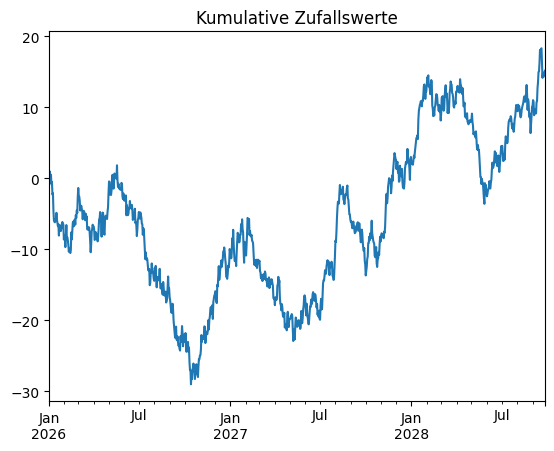

Nun ein DataFrame mit vier Spalten, ebenfalls kumuliert und gemeinsam geplottet.


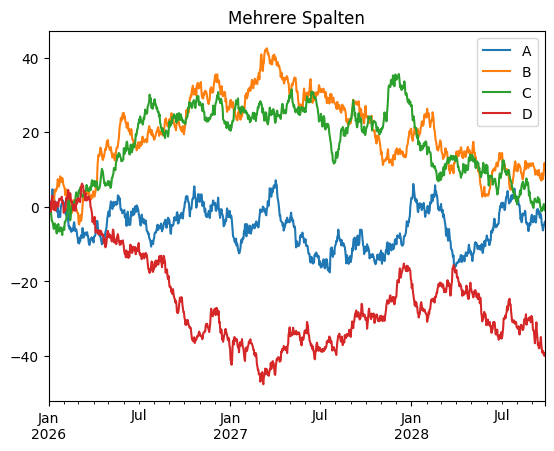

In [13]:
print("Wir erzeugen eine kumulative Zufallsreihe. Durch cumsum() entsteht eine gut sichtbare Entwicklung uber die Zeit.")
ts_plot = pd.Series(np.random.randn(1000), index=pd.date_range("2026-01-01", periods=1000))
ts_plot = ts_plot.cumsum()
ts_plot.plot(title="Kumulative Zufallswerte")
plt.show()

print("Nun ein DataFrame mit vier Spalten, ebenfalls kumuliert und gemeinsam geplottet.")
df_plot = pd.DataFrame(np.random.randn(1000, 4), index=ts_plot.index, columns=list("ABCD"))
df_plot = df_plot.cumsum()
df_plot.plot(title="Mehrere Spalten")
plt.show()

## 11. Speichern und Laden

Zum Schluss speichern wir das DataFrame zuerst als CSV und danach auch als Excel-Datei.

Fur den Excel-Export verwenden wir `XlsxWriter`. Falls das Paket in der `.venv` noch fehlt, kannst du es mit folgendem Befehl installieren:

```bash
uv add xlsxwriter
```

In [14]:
csv_path = Path("example_pandas.csv")
print(f"Wir speichern df als CSV nach: {csv_path.resolve()}")
df.to_csv(csv_path)

print("Anschliessend laden wir die Datei wieder ein.")
loaded_csv = pd.read_csv(csv_path, index_col=0)
display(loaded_csv.head())

Wir speichern df als CSV nach: C:\Users\UlrichLehre\Documents\260324_LV3\notebooks\example_pandas.csv
Anschliessend laden wir die Datei wieder ein.


,A,B,C,D
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-02,-0.450053,0.701662,-0.313922,0.072660
2026-01-03,0.567786,0.443814,-0.852549,0.703371
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888
2026-01-05,-0.496390,-0.034001,-0.035085,-0.354269


In [17]:
excel_path = Path("example_pandas.xlsx")
has_xlsxwriter = importlib.util.find_spec("xlsxwriter") is not None

print("Fur diesen Excel-Export verwenden wir gezielt XlsxWriter als Engine.")
print(f"xlsxwriter installiert: {has_xlsxwriter}")

if has_xlsxwriter:
    print(f"Wir speichern df als Excel-Datei nach: {excel_path.resolve()}")
    df.to_excel(excel_path, engine="xlsxwriter")
    loaded_excel = pd.read_excel(excel_path, index_col=0)
    print("Die Excel-Datei wurde geschrieben und wieder eingelesen.")
    display(loaded_excel.head())
else:
    print("XlsxWriter ist noch nicht installiert.")
    print("Installiere es in der Projekt-.venv mit: uv add xlsxwriter")

Fur diesen Excel-Export verwenden wir gezielt XlsxWriter als Engine.
xlsxwriter installiert: True
Wir speichern df als Excel-Datei nach: C:\Users\UlrichLehre\Documents\260324_LV3\notebooks\example_pandas.xlsx
Die Excel-Datei wurde geschrieben und wieder eingelesen.


,A,B,C,D
2026-01-01,0.939088,0.076129,1.152824,0.342113
2026-01-02,-0.450053,0.701662,-0.313922,0.072660
2026-01-03,0.567786,0.443814,-0.852549,0.703371
2026-01-04,-0.477088,-0.244998,-1.425341,0.039888
2026-01-05,-0.496390,-0.034001,-0.035085,-0.354269
